# ML & DL Exam


**Import and Util functions**

In [1]:
#------------------------------
# Global Variables
#------------------------------
SEED = 42

#------------------------------
# Global import
#------------------------------
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
import numpy as np
from typing import List, Optional, Tuple, Dict, Union


In [2]:
def plot_heatmap(
    data_i: np.ndarray,
    title_i: str = 'Heatmap',
    color_i: str = 'coolwarm',
    format_i: str = '.2f'
) -> None:
    """
    Plot an Heat-map of the matrix given as data_i input.

    Parameters
    ----------
    data_i : array_like
        data matrix to plot
    title_i : str
        title of the plot. Default is 'Heatmap'
    color_i : str
        color map to use. Default is 'coolwarm'
    format_i : str
        format of the values to plot. Default is '.2f'

    Return
    -------
    None
    """
    

    fig = plt.figure(figsize=[5.4, 3.8], dpi=300)
    ax = fig.add_axes([0,0,1,1])
    sns.heatmap(data_i, annot=True, cmap=color_i, fmt=format_i)
    plt.title(title_i)
    plt.tight_layout()
    plt.show()

########################################

def plot_scatter(
  data_i: np.ndarray,
  classes_i: np.ndarray = None,
  labels_i: list[str] = None,
  marker_i: str = None,
  title_i: str = 'Scatter plot',
  xlabel_i: str = 'xlabel',
  ylabel_i: str = 'ylabel'
) -> None:
    """
    Plot the Scatter plot of the data_i.

    Parameters
    ----------
    data_i : array_like
        data matrix to plot. Data are arranged by rows,
        columns are the axis (x, y)
    classes_i: array_like, default=None
        list of classes to plot. Default is None.
        If classes is not None, labels shall be provided.
    labels_i : list[str]        labels of the plot. Default is None.
        If Labels is not None, a mask is appled to the rows of
        the data_i and only the rows of data_i and a scatter is plotted
        for each lablel (i.e. a class).
    marker_i : str
        marker to use. Default is None

    title_i : str
        title of the plot. Default is 'Scatter plot'
    xlabel_i : str
        label of the x-axis. Default is 'xlabel'
    ylabel_i : str
        label of the y-axis. Default is 'ylabel'
    Return
    ------
    None
    """

    plt.figure(figsize=[6, 4.5], dpi=300)
    plt.xlabel(xlabel_i)
    plt.ylabel(ylabel_i)
    plt.title(title_i)

    if(labels_i != None):

        for idx, l in enumerate(labels_i):
            plt.scatter(x=data_i[ idx == classes_i, 0], y=data_i[ idx == classes_i, 1], 
                marker=marker_i, label=l, alpha=0.6)
        plt.legend()

    else:
        plt.scatter(x=data_i[:, 0], y=data_i[:, 1], marker=marker_i)

    plt.tight_layout()
    plt.show()

########################################

def plot_scatter_3d(
  data_i: np.ndarray,
  classes_i: np.ndarray = None,
  labels_i: list[str] = None,
  marker_i: str = None,
  title_i: str = '3D Scatter plot',
  xlabel_i: str = 'xlabel',
  ylabel_i: str = 'ylabel',
  zlabel_i: str = 'zlabel'
) -> None:
    """
    Plot the 3D Scatter plot of the data_i.

    Parameters
    ----------
    data_i : array_like
        data matrix to plot. Data are arranged by rows,
        columns are the axis (x, y, z)
    classes_i: array_like, default=None
        list of classes to plot. Default is None.
        If classes is not None, labels shall be provided.
    labels_i : list[str]
        labels of the plot. Default is None.
        If Labels is not None, a mask is appled to the rows of
        the data_i and only the rows of data_i and a scatter is plotted
        for each lablel (i.e. a class).
    marker_i : str
        marker to use. Default is None

    title_i : str
        title of the plot. Default is '3D Scatter plot'
    xlabel_i : str
        label of the x-axis. Default is 'xlabel'
    ylabel_i : str
        label of the y-axis. Default is 'ylabel'
    zlabel_i : str
        label of the z-axis. Default is 'zlabel'
    Return
    ------
    None
    """

    fig = plt.figure(figsize=[6, 4.5], dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlabel(xlabel_i)
    ax.set_ylabel(ylabel_i)
    ax.set_zlabel(zlabel_i)
    ax.set_title(title_i)

    if(labels_i != None):

        for idx, l in enumerate(labels_i):
            ax.scatter(xs=data_i[ idx == classes_i, 0], ys=data_i[ idx == classes_i, 1], zs=data_i[ idx == classes_i, 2], 
                marker=marker_i, label=l, alpha=0.6)
        ax.legend()

    else:
        ax.scatter(xs=data_i[:, 0], ys=data_i[:, 1], zs=data_i[:, 2], marker=marker_i)

    plt.tight_layout()
    plt.show()

########################################

def study_correlation(
    df: pd.DataFrame, abs_val: bool = True, tri_sup: bool = True, threshold: Optional[float] = None
) -> Tuple[np.ndarray, Optional[List[int]]]:
    """
    Computes the correlation matrix for a DataFrame with options for absolute values
    and upper triangular filtering. Optionally identifies column indices exceeding a correlation threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Input Pandas DataFrame containing numerical features.
    abs_val : bool, default=True
        If True, takes the absolute value of the correlation matrix.
    tri_sup : bool, default=True
        If True, retains only the upper triangular part of the matrix (where j > i),
        setting all other entries to zero.
    threshold : float, optional
        Correlation threshold. If provided, returns a list of column indices where correlation
        exceeds this threshold.

    Returns
    -------
    Tuple[np.ndarray, Optional[dict]]: 
        - np.ndarray: Processed correlation matrix.
        - Optional[dict]: Dictionary with keys as (j, i) = feature j correlated with feature i (where j > i), 
              and values as the correlation value, or None if threshold is not provided.
    """
    corr_matrix = (df.corr()).to_numpy()
    if abs_val:
        corr_matrix = np.abs(corr_matrix)
    
    if tri_sup:
        corr_sup = np.zeros(corr_matrix.shape)
        for i in range(0, corr_sup.shape[0]):
            for j in range(0, corr_sup.shape[0]):
                if j > i:
                    corr_sup[i, j] = corr_matrix[i, j]
        corr_matrix = corr_sup

    high_corr: Optional[dict] = None
    if threshold is not None:
        high_corr = {}
        for i in range(corr_matrix.shape[0]):
            for j in range(i + 1, corr_matrix.shape[1]):
                if corr_matrix[i, j] >= threshold:
                    high_corr[(i, j)] = corr_matrix[i, j]
    return corr_matrix, high_corr
    
######################################## 

def remove_correlated_features(
    X: Union[pd.DataFrame, np.ndarray], high_corr: Dict[Tuple[int, int], float]
) -> Tuple[Union[pd.DataFrame, np.ndarray], np.ndarray]:
    """
    Removes correlated features from the feature matrix based on the high_corr dictionary.
    For each correlated pair (i, j) with i < j, if feature i is maintained, feature j is dropped.

    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Matrix of features (samples x features).
    high_corr : Dict[Tuple[int, int], float], optional
        Dictionary mapping feature index pairs (i, j) to their correlation values.
        If None, no features are removed.

    Returns
    -------
    Tuple[pd.DataFrame or np.ndarray, np.ndarray]
        - X_filtered : Matrix containing only the maintained features.
        - support : Boolean 1D NumPy array indicating which features were maintained (True) or dropped (False).
    """
    n_features = X.shape[1]
    support = np.ones(n_features, dtype=bool)

    for i in range(n_features):
        if support[i]:
            for j in range(i + 1, n_features):
                if (i, j) in high_corr or (j, i) in high_corr:
                    support[j] = False

    if isinstance(X, pd.DataFrame):
        X_filtered = X.iloc[:, support]
    else:
        X_filtered = X[:, support]

    return X_filtered, support

## 1. Data Preparation

In [4]:
#------------------------------
# Train Dataset
#------------------------------

DATASET_PATH = "./Dataset/train_dataset.csv"

# Load training set in a Pandas Dataframe
df = pd.read_csv(DATASET_PATH)

# Store target number and label
y_train = df['target'].to_numpy(dtype=int)
targets_names = list( df['target_name'].unique() )
features_names = df.columns.to_numpy(dtype=str)

print('Dataset shape: ', df.shape)
print('Imported dataframe:\n', df.head(), '\n')

# Remove subject id, target name (which is string so gives problems) and target
# Store _original to preserve a copy from changes
X_original = df.drop(labels=['subject_id', 'target_name', 'target'], axis=1)
features_names_original = features_names[1 : -2].copy()

# print('Features_name_original: ', features_names_original, '\n')

# Re-assign names
X_train = X_original.copy()
features_names = features_names_original

# Visualize the dataset
print('Cleaned dataframe:\n', X_train.head(), '\n')

Dataset shape:  (7352, 564)
Imported dataframe:
    subject_id  tBodyAcc-mean()-X  ...  target_name  target
0           1           0.288585  ...     STANDING       4
1           1           0.278419  ...     STANDING       4
2           1           0.279653  ...     STANDING       4
3           1           0.279174  ...     STANDING       4
4           1           0.276629  ...     STANDING       4

[5 rows x 564 columns] 

Cleaned dataframe:
    tBodyAcc-mean()-X  ...  angle(Z,gravityMean)
0           0.288585  ...             -0.058627
1           0.278419  ...             -0.054317
2           0.279653  ...             -0.049118
3           0.279174  ...             -0.047663
4           0.276629  ...             -0.043892

[5 rows x 561 columns] 



In [5]:
#------------------------------
# Test Dataset
#------------------------------

TEST_DATASET_PATH = "./Dataset/test_dataset.csv"

# Load training set in a Pandas Dataframe
df_test = pd.read_csv(TEST_DATASET_PATH)

print('Dataset shape: ', df_test.shape)
print('Imported dataframe:\n', df_test.head(), '\n')

# Store test targets
y_test = df_test['target'].to_numpy(dtype=int)

# Remove subject id, target name (which is string so gives problems) and target
# Store _original to preserve a copy from changes
X_test = df_test.drop(labels=['subject_id', 'target_name', 'target'], axis=1)

# Visualize the dataset
print('Cleaned dataframe:\n', X_test.head(), '\n')

Dataset shape:  (2947, 564)
Imported dataframe:
    subject_id  tBodyAcc-mean()-X  ...  target_name  target
0           2           0.257178  ...     STANDING       4
1           2           0.286027  ...     STANDING       4
2           2           0.275485  ...     STANDING       4
3           2           0.270298  ...     STANDING       4
4           2           0.274833  ...     STANDING       4

[5 rows x 564 columns] 

Cleaned dataframe:
    tBodyAcc-mean()-X  ...  angle(Z,gravityMean)
0           0.257178  ...             -0.057978
1           0.286027  ...             -0.083898
2           0.275485  ...             -0.079346
3           0.270298  ...             -0.077108
4           0.274833  ...             -0.073857

[5 rows x 561 columns] 



**Try classification with the whole dataset**

In [ ]:
#------------------------------
# Import
#------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

#------------------------------
# Standardization
#------------------------------
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

#------------------------------
# Classification
#------------------------------
rf = RandomForestClassifier(criterion='gini', n_estimators=400, max_features='sqrt', min_samples_split=10, 
        bootstrap=True, oob_score=True, random_state=SEED)

# Fit
rf.fit(X_train_std, y_train)

# Evluation on training set
y_pred = rf.predict(X_test_std)

# Evaluation
print( classification_report( y_test, y_pred, target_names=targets_names ) )
plot_heatmap(confusion_matrix(y_test, y_pred), title_i='Confusion Matrix')

### 1.1. Statistics

In [ ]:
# Main statistics
X_train.describe()


**Study the correlation**

In [ ]:
#------------------------------
# Correlation matrix 
#------------------------------ 
corr_matrix, corr_features = study_correlation(X_train, threshold = 0.8)
print(len(corr_features))

#------------------------------
# Clean up
#------------------------------ 

# Remove the features more correlated than 80%
X_train_uncorr, support = remove_correlated_features(X_train, corr_features)
print('New feature matrix shape: ', X_train_uncorr.shape, '\n')

features_name_uncorr = features_names[support].copy()

# Print the remained features
# for i in range (features_name_uncorr.shape[0]):
#     if(i % 4 == 0):
#         print()
#     print(features_name_uncorr[i])

# Build the dataset again
X_train_uncorr = pd.DataFrame(X_train_uncorr, columns=features_name_uncorr)

In [ ]:
#------------------------------
# Apply to Test
#------------------------------ 
X_test_uncorr, _ = remove_correlated_features(X_test, corr_features)

# Build the dataset again
X_test_uncorr = pd.DataFrame(X_test_uncorr, columns=features_name_uncorr)

print('New test matrix shape: ', X_test_uncorr.shape, '\n')

### 1.2 Dimensionality reduction

**Study the variance**

In [ ]:
#------------------------------
# Import
#------------------------------
from sklearn.feature_selection import VarianceThreshold

#------------------------------
# Variance analysic
#------------------------------

# Compute features variance
variance = X_train.var()
variance.sort_values(ascending=False)
# print("Variance for featues:\n", variance, '\n')

vt = VarianceThreshold(threshold=0.1) # 0.1 arbitrary
X_var = vt.fit_transform(X_train)
print('X shape after maintaining 90% of the variance ', X_var.shape, '\n')

# Reput X_var in a dataframe
X_var = pd.DataFrame(data=X_var, columns=X_train.columns[ vt.get_support() ] )
X_var.head()

***PCA***

In [ ]:
#------------------------------
# Costants
#------------------------------
VARIANCE_TO_PRESERVE = 0.01

In [ ]:
#------------------------------
# Import
#------------------------------
from sklearn.decomposition import PCA

# Trying to reduce the dimensionality with PCA
pca = PCA(n_components=0.9) 
X_train_pca = pca.fit_transform(X_train_uncorr)

print('X shape after PCA with 90% application: ', X_train_pca.shape, '\n')
print('PCA explained variance ratio: ', pca.explained_variance_ratio_)

#------------------------------
# Build new DF
#------------------------------
X_preserved = X_train_pca[:, pca.explained_variance_ratio_ > VARIANCE_TO_PRESERVE].copy()

X_train_pca = pd.DataFrame( X_preserved, columns=[f'feat_{i}' for i in range(X_preserved.shape[1])] )
print('Train dataset shape after PCA: ', X_train_pca.shape, '\n')


In [ ]:
#------------------------------
# Apply to Test
#------------------------------ 

X_test_pca = pca.transform(X_test_uncorr)
X_test_preserved = X_test_pca[:, pca.explained_variance_ratio_ > VARIANCE_TO_PRESERVE].copy()

# Build DataFrame again
X_test_pca = pd.DataFrame( X_test_preserved, columns=[f'feat_{i}' for i in range(X_test_preserved.shape[1])] )
print('Test dataset shape after PCA: ', X_test_pca.shape, '\n')

**Transformed features statistics**

In [ ]:
X_train_pca.describe()

**LDA**

In [9]:
#------------------------------
# Import
#------------------------------
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA 

lda = LDA()
X_train_lda = lda.fit_transform(X_train, y_train)

#------------------------------
# Build new DF
#------------------------------
X_train_lda = pd.DataFrame( X_train_lda, columns=lda.get_feature_names_out() )

In [12]:
#------------------------------
# Apply to Test
#------------------------------ 
X_test_lda = lda.transform(X_test)

#------------------------------
# Build new DF
#------------------------------
X_test_lda = pd.DataFrame( X_test_lda, columns=lda.get_feature_names_out() )

### 1.3 Data visualization and patterns search

***Features standardization***

In [13]:
#------------------------------
# Import
#------------------------------
from sklearn.preprocessing import StandardScaler

#------------------------------
# Standardization
#------------------------------
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_lda)
X_test_std = scaler.transform(X_test_lda)

**Use t-SNE to visualize the data in 2D**

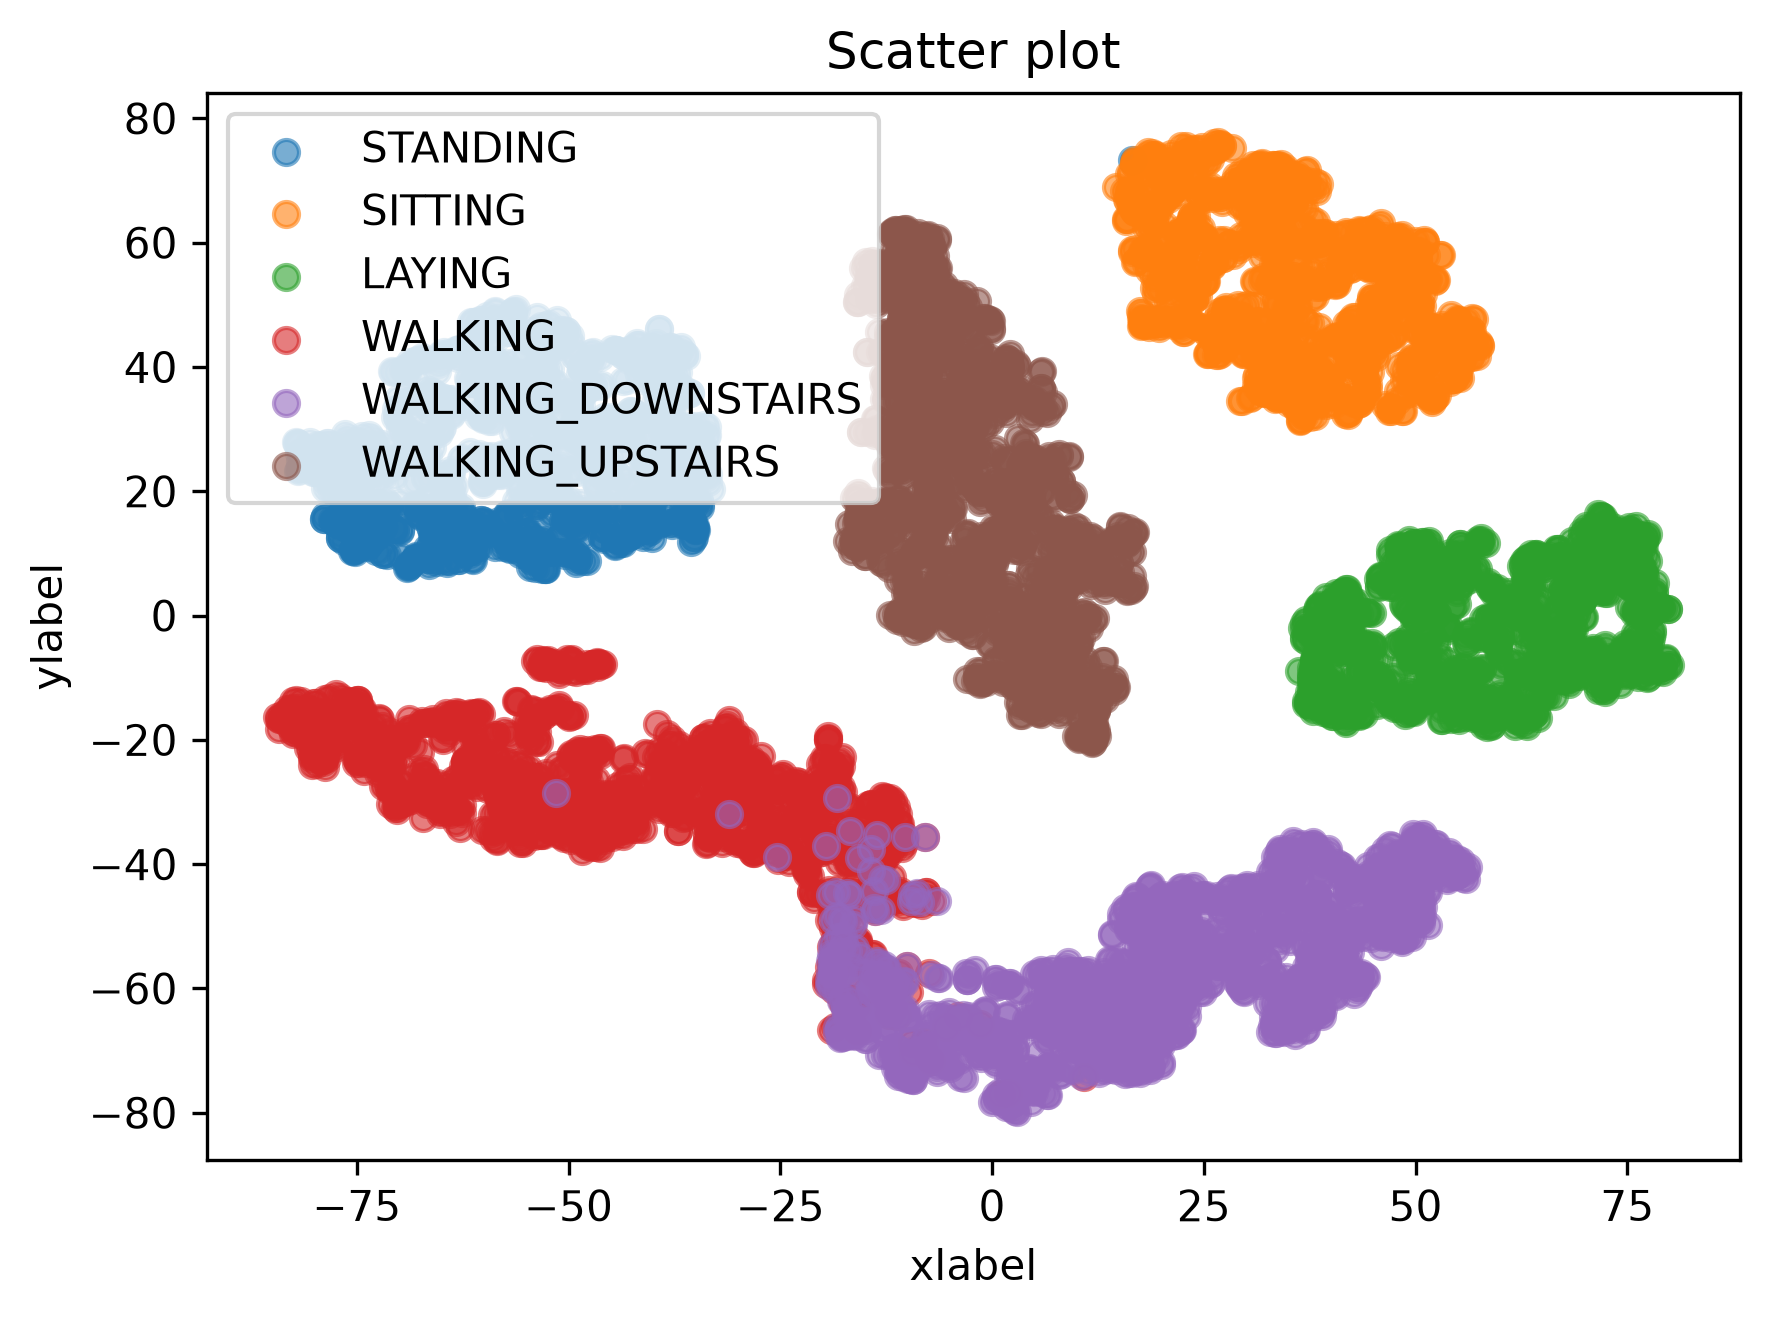

In [15]:
#------------------------------
# Import
#------------------------------
from sklearn.manifold import TSNE

#------------------------------
# Analysis
#------------------------------

# t-SNE projection in 2D
t_sne = TSNE(n_components=2, random_state=SEED, perplexity=30, learning_rate=200)
X_2d = t_sne.fit_transform(X_train_std)

plot_scatter(X_2d, classes_i=y_train, labels_i=targets_names)

# t-SNE projection in 3D
# t_sne = TSNE(n_components=3, random_state=SEED, perplexity=30, learning_rate=200)
# X_3d = t_sne.fit_transform(X_train_std)

# plot_scatter_3d(X_3d, classes_i=y_train, labels_i=targets_names)

## 2. Classification

                    precision    recall  f1-score   support

          STANDING       0.97      0.99      0.98       496
           SITTING       0.98      0.97      0.98       471
            LAYING       1.00      0.98      0.99       420
           WALKING       0.96      0.86      0.91       491
WALKING_DOWNSTAIRS       0.88      0.96      0.92       532
  WALKING_UPSTAIRS       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



/var/folders/j2/ly_gk9s162l3tbyb8nfbcdsm0000gn/T/ipykernel_13650/4259549461.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


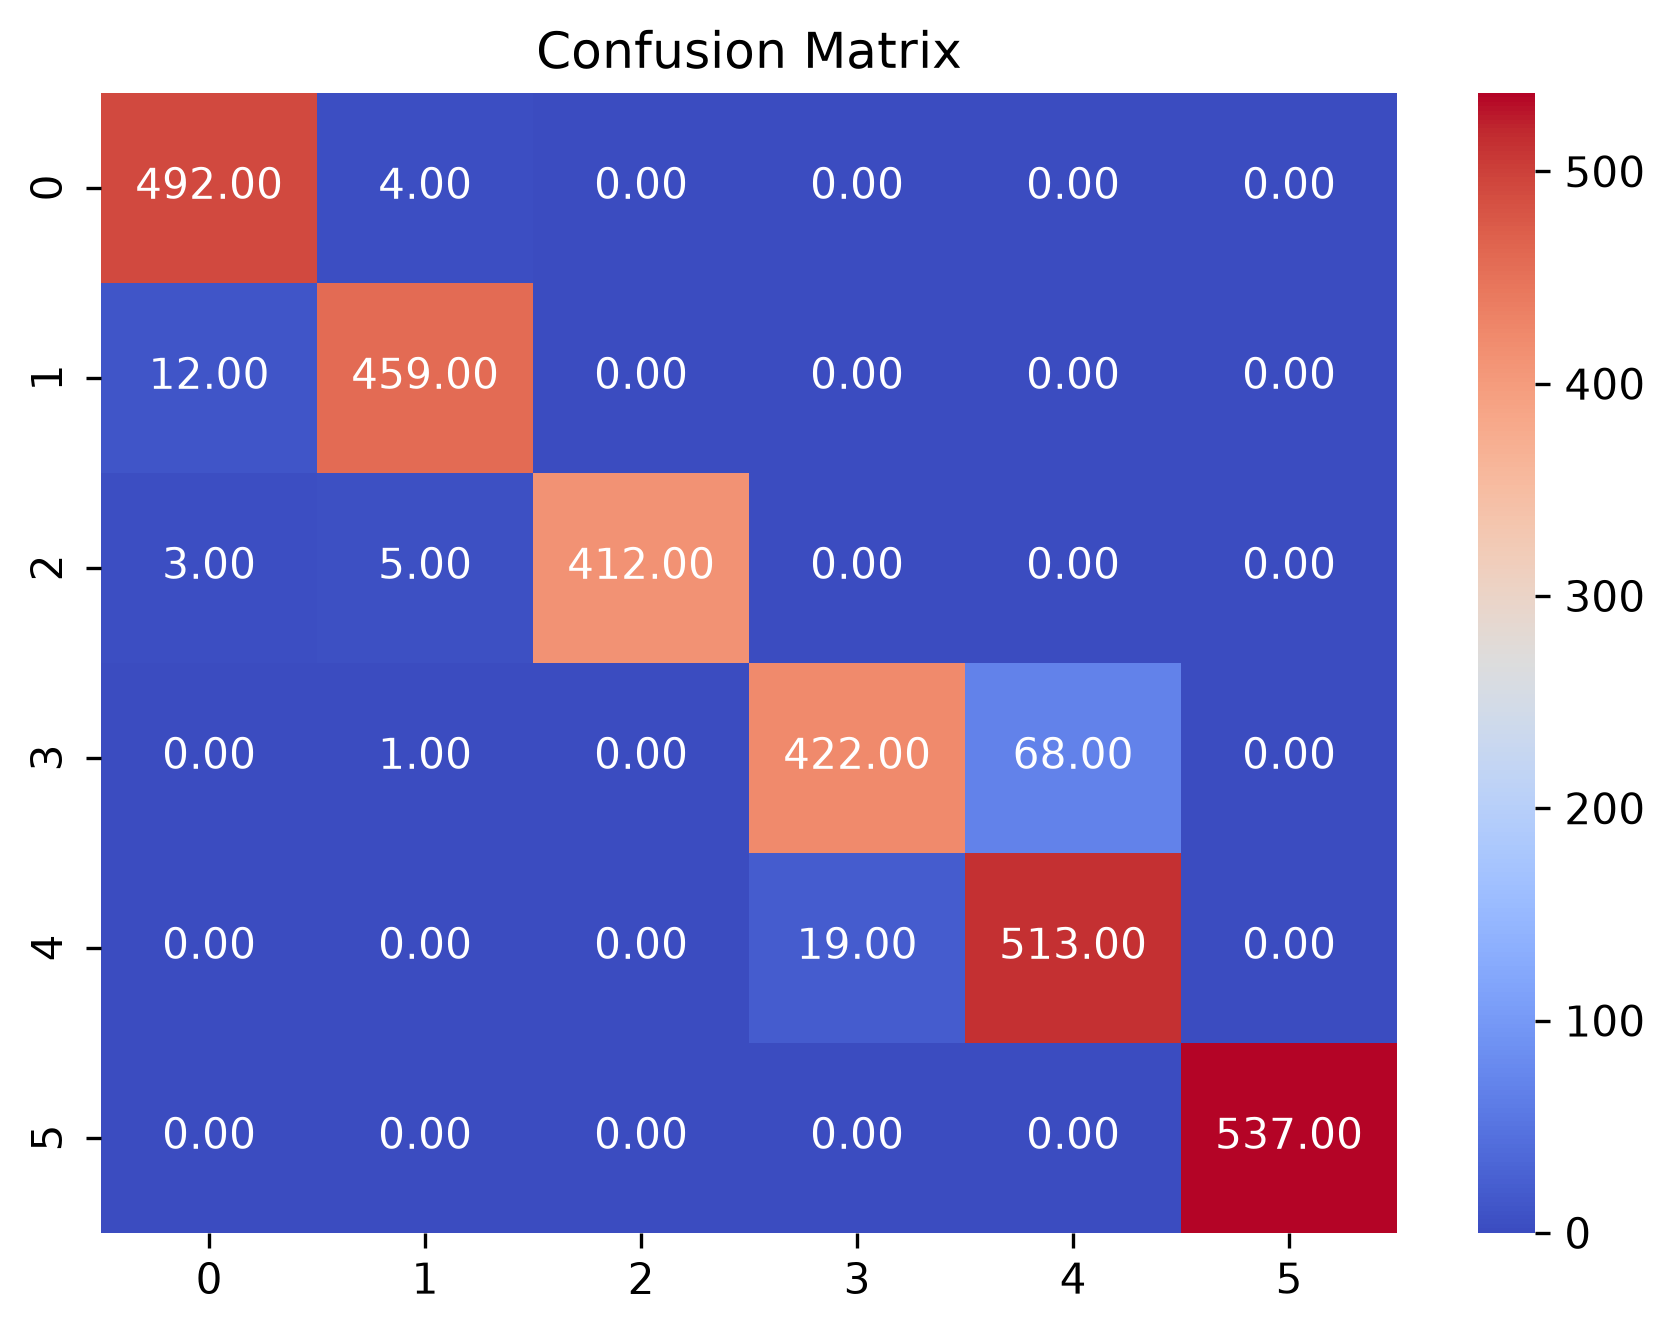

In [16]:
#------------------------------
# Import
#------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#------------------------------
# Classification
#------------------------------
rf = RandomForestClassifier(criterion='gini', n_estimators=400, max_features='sqrt', min_samples_split=10, 
        bootstrap=True, oob_score=True, random_state=SEED)

# Fit
rf.fit(X_train_std, y_train)

# Evluation on training set
y_pred = rf.predict(X_test_std)

# Evaluation
print( classification_report( y_test, y_pred, target_names=targets_names ) )
plot_heatmap(confusion_matrix(y_test, y_pred), title_i='Confusion Matrix')
